# Problématique 

# Analyse Exploratoire des Données

#### Import des bibliothèques 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


#### Compréhension de nos données 

In [3]:
df = pd.read_csv('ab_data.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [6]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


(294478, 5)

In [8]:
df.describe(include='all')

,user_id,timestamp,group,landing_page,converted
count,294478.000000,294478,294478,294478,294478.000000
unique,NaN,294478,2,2,NaN
top,NaN,2017-01-21 22:11:48.556739,treatment,old_page,NaN
freq,NaN,1,147276,147239,NaN
mean,787974.124733,NaN,NaN,NaN,0.119659
std,91210.823776,NaN,NaN,NaN,0.324563
min,630000.000000,NaN,NaN,NaN,0.000000
25%,709032.250000,NaN,NaN,NaN,0.000000
50%,787933.500000,NaN,NaN,NaN,0.000000
75%,866911.750000,NaN,NaN,NaN,0.000000


#### Détection des valeurs manquantes

In [9]:
missing_tableau = pd.DataFrame(
    {
        'Somme': df.isnull().sum(),
        'Frequence' : df.isnull().sum() / len(df) *100
    }
)
print(missing_tableau)

              Somme  Frequence
user_id           0        0.0
timestamp         0        0.0
group             0        0.0
landing_page      0        0.0
converted         0        0.0


Nous remarquons qu'il n'y a pas de valeurs manquantes 

#### Détection des doublons

In [10]:
doublons = df.duplicated().sum()
print(f'Nous remarquons que nous avons {doublons} doublons')

Nous remarquons que nous avons 0 doublons


Pas de doublons non plus 

#### Distribution des variables 

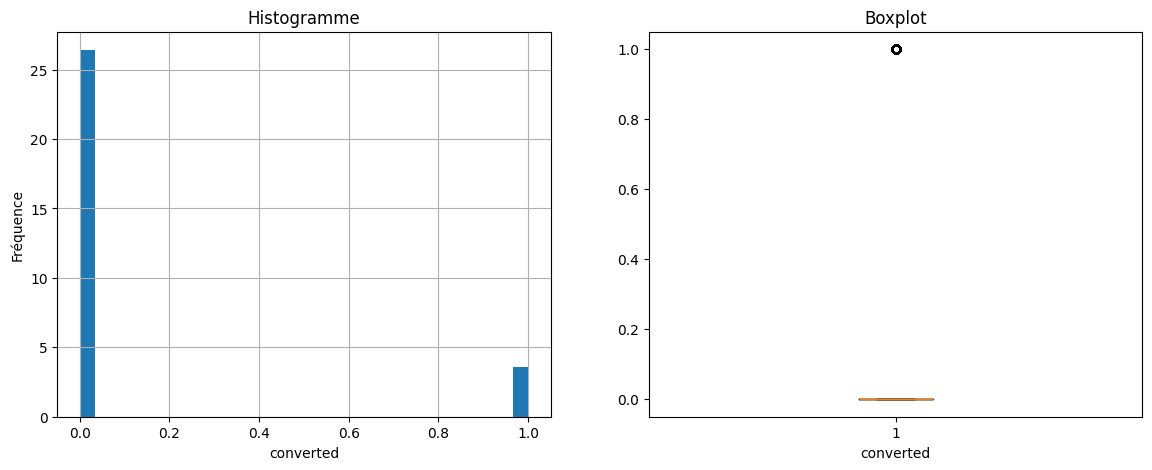

In [19]:
dis_var= df['converted']
dis_var
figure, ax = plt.subplots(1,2,figsize=(14, 5))
ax[0].hist(dis_var, bins=30, density=True)
ax[0].set_title('Histogramme')
ax[0].set_xlabel('converted')
ax[0].set_ylabel('Fréquence')
ax[0].grid()
ax[1].boxplot(dis_var)
ax[1].set_title('Boxplot')
ax[1].set_xlabel('converted') 
figure.savefig('images/distribution_converted.png')

#### Détection des outliers

In [25]:
# sur le plan univarié 
# méthode IQR 
def detec_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    borne_infer = Q1 - (1.5 * IQR)
    borne_super = Q3 + (1.5 * IQR)

    return data[(data[column] < borne_infer) | (data[column] > borne_super)]

outliers = detec_outliers(df, 'converted')
print('Outliers détectés')
print(outliers)

Outliers détectés
        user_id                   timestamp      group landing_page  converted
4        864975  2017-01-21 01:52:26.210827    control     old_page          1
6        679687  2017-01-19 03:26:46.940749  treatment     new_page          1
8        817355  2017-01-04 17:58:08.979471  treatment     new_page          1
9        839785  2017-01-15 18:11:06.610965  treatment     new_page          1
15       644214  2017-01-22 02:05:21.719434    control     old_page          1
...         ...                         ...        ...          ...        ...
294396   838593  2017-01-15 09:56:31.455023  treatment     new_page          1
294405   712217  2017-01-11 10:34:30.176801    control     old_page          1
294420   795742  2017-01-09 01:06:58.299207    control     old_page          1
294430   733871  2017-01-21 17:54:08.810964  treatment     new_page          1
294443   665217  2017-01-10 23:29:01.767720    control     old_page          1

[35237 rows x 5 columns]


In [26]:
# Isolation Forest (sur variables numériques uniquement)
from sklearn.ensemble import IsolationForest

# 1) Garder seulement les colonnes numériques
X_iso = df.select_dtypes(include=[np.number]).copy()

# 2) Retirer une éventuelle colonne cible déjà créée
if 'Outlier' in X_iso.columns:
    X_iso = X_iso.drop(columns=['Outlier'])



iso_forest = IsolationForest(contamination=0.001, random_state=42)
outlier_labels = iso_forest.fit_predict(X_iso)

df['Outlier'] = outlier_labels
outliers = df[df['Outlier'] == -1]

print('Outliers détectés (Isolation Forest)')
n_outliers_iso = (outlier_labels == -1).sum()
print(f"Outliers détectés : {n_outliers_iso} ({n_outliers_iso/len(df)*100:.2f}%)")
print(f"Colonnes utilisées : {X_iso.shape[1]}")

Outliers détectés (Isolation Forest)
Outliers détectés : 248 (0.08%)
Colonnes utilisées : 2


Dans l'AB testing  la détection des outliers est moins critique donc nous allons travailler avec ses outliers

#### Taux de conversion - Visualisation 

- control → Groupe A → bouton orange
- treatment → Groupe B → bouton vert

In [27]:
# Taux de conversion groupe Control
taux_control = df[df['group']=='control']['converted'].mean()

# Taux de conversion groupe Treatment  
taux_treatment = df[df['group']=='treatment']['converted'].mean()

print(f"Bouton orange : {taux_control:.2%}")
print(f"Bouton vert : {taux_treatment:.2%}")

Bouton orange : 12.04%
Bouton vert : 11.89%


<Axes: xlabel='group', ylabel='count'>

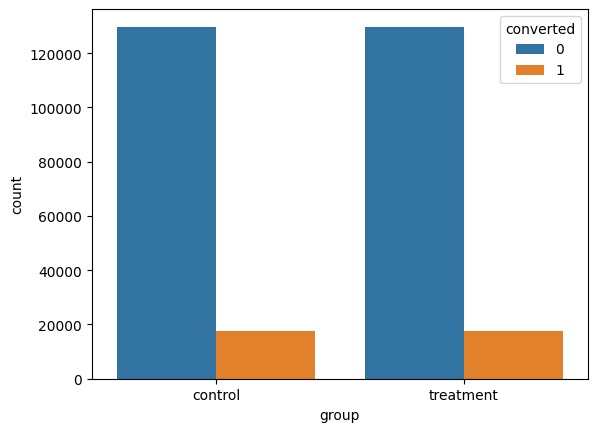

In [28]:
# Répartition des groupes
df['group'].value_counts()

# Répartition converted
df['converted'].value_counts()

# Visualisation
sns.countplot(x='group', hue='converted', data=df)

# Sanity Check - Vérification de l'équilibre des groupes

#### Asignation groupe/page

In [31]:
# Control doit voir UNIQUEMENT old_page
control = df[df['group'] == 'control']['landing_page'].value_counts()

# Treatment doit voir UNIQUEMENT new_page  
treatment = df[df['group'] == 'treatment']['landing_page'].value_counts()

print(control)
print(treatment)

landing_page
old_page    145274
new_page      1928
Name: count, dtype: int64
landing_page
new_page    145311
old_page      1965
Name: count, dtype: int64


Nous remarquons un problème le groupe control ont vu la nouvelle page et le groupe treatment ont vu la mauvaise page 

In [32]:
# Garder seulement les lignes correctement assignées
df_clean = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
]

print(f"Avant nettoyage : {len(df)}")
print(f"Après nettoyage : {len(df_clean)}")
print(f"Lignes supprimées : {len(df) - len(df_clean)}")

Avant nettoyage : 294478
Après nettoyage : 290585
Lignes supprimées : 3893


#### Vérification des doublons 

Aucun doublon détecté 

#### Vérification -Groupes équilibrés 

In [30]:
df['group'].value_counts(normalize=True)

group
treatment    0.500126
control      0.499874
Name: proportion, dtype: float64

# Solution Statistique 

#### Vérification de la normalité 

On a 294478 observations .Ainsi d'après le théorème central limite alors l'echantillon suit une distribution normale 

#### Vérification de l'égalité des variances 



In [33]:
from scipy import stats
stats.levene(df[df['group'] == 'control']['converted'], df[df['group'] == 'treatment']['converted'])

LeveneResult(statistic=np.float64(1.5299729852804425), pvalue=np.float64(0.21611748562490823))

la p-value est supérieur à 0.05 alors les variances sont égales .


#### Choix du test statistique

>L'échantillon suit une distribution normale et les variances sont égales .Alors le test approprié serait le t-student. Cependant étant en face d'une grande échantillon le test approprié est le Z-test

### Les hypothèses


- H0 — Hypothèse nulle
    Il n’y a pas de différence significative entre le taux de conversion du bouton orange et du bouton vert
    p_control = p_treatment
- H1 — Hypothèse alternative
    Il existe une différence significative entre les deux taux de conversion
    p_control ≠ p_treatment
    Seuil de signification
    α = 0.05 — si p-value < 0.05 on rejette H0

#### Calcul de la p-value et conclusion business 

In [34]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Nombre de conversions par groupe
conversions_control = df_clean[df_clean['group'] == 'control']['converted'].sum()
conversions_treatment = df_clean[df_clean['group'] == 'treatment']['converted'].sum()

# Nombre total d'observations par groupe
n_control = len(df_clean[df_clean['group'] == 'control'])
n_treatment = len(df_clean[df_clean['group'] == 'treatment'])

# Taux de conversion
taux_control = conversions_control / n_control
taux_treatment = conversions_treatment / n_treatment

print(f"Taux Control (bouton orange)   : {taux_control:.4f} ({taux_control:.2%})")
print(f"Taux Treatment (bouton vert)   : {taux_treatment:.4f} ({taux_treatment:.2%})")
print(f"Différence absolue             : {abs(taux_treatment - taux_control):.4f}")
print(f"Lift                           : {((taux_treatment - taux_control) / taux_control):.2%}")

# Z-test
stat, p_value = proportions_ztest(
    count=[conversions_control, conversions_treatment],
    nobs=[n_control, n_treatment],
    alternative='two-sided'  # bilatéral ← H1 : ≠
)

print(f"\nZ-statistique : {stat:.4f}")
print(f"P-value       : {p_value:.4f}")

# Conclusion
alpha = 0.05
if p_value < alpha:
    print(f"\n✅ P-value ({p_value:.4f}) < α ({alpha})")
    print("→ On REJETTE H0")
    print("→ Il existe une différence significative entre les deux boutons")
    if taux_treatment > taux_control:
        print("→ Le bouton VERT convertit mieux 🟢")
    else:
        print("→ Le bouton ORANGE convertit mieux 🟠")
else:
    print(f"\n❌ P-value ({p_value:.4f}) > α ({alpha})")
    print("→ On NE REJETTE PAS H0")
    print("→ Pas de différence significative — garder l'ancien bouton 🟠")

Taux Control (bouton orange)   : 0.1204 (12.04%)
Taux Treatment (bouton vert)   : 0.1188 (11.88%)
Différence absolue             : 0.0016
Lift                           : -1.31%

Z-statistique : 1.3116
P-value       : 0.1897

❌ P-value (0.1897) > α (0.05)
→ On NE REJETTE PAS H0
→ Pas de différence significative — garder l'ancien bouton 🟠


# Réponses aux questions business 

In [35]:
diff = taux_treatment - taux_control
lift = diff / taux_control
print(f"Taux de conversion Groupe A (control): {taux_control:.4f} ({taux_control:.2%})")
print(f"Taux de conversion Groupe B (treatment): {taux_treatment:.4f} ({taux_treatment:.2%})")
print(f"Difference absolue (B - A): {diff:.4f} ({diff:.2%})")
print(f"Lift relatif: {lift:.2%}")
print(f"p-value: {p_value:.6f}")
print("Significatif au seuil 5%:", p_value < 0.05)

Taux de conversion Groupe A (control): 0.1204 (12.04%)
Taux de conversion Groupe B (treatment): 0.1188 (11.88%)
Difference absolue (B - A): -0.0016 (-0.16%)
Lift relatif: -1.31%
p-value: 0.189653
Significatif au seuil 5%: False



Voici la synthèse basée sur tes résultats actuels :

1. Le nouveau bouton vert convertit-il significativement mieux ?
Non.  
La p-value est 0.189653, donc supérieure à 0.05. On ne rejette pas H0 : il n’y a pas de différence statistiquement significative entre les deux boutons.

2. Quelle est la différence réelle de taux de conversion ?
- Groupe A (control, ancien bouton) : 12.04%
- Groupe B (treatment, bouton vert) : 11.88%
- Différence absolue (B - A) : -0.16 point de pourcentage
- Lift relatif : -1.31%

Donc dans cet échantillon, le bouton vert fait légèrement moins bien.

3. Peut-on généraliser à tous les visiteurs ?
Pas avec ce résultat.  
Comme le test n’est pas significatif, la différence observée peut être due au hasard d’échantillonnage.

4. Faut-il déployer le nouveau bouton ?
Recommandation actuelle : garder l’ancien bouton (Groupe A).  
Le bouton vert n’apporte pas de gain mesurable ici.

KPIs attendus :
- Taux de conversion Groupe A : 12.04%
- Taux de conversion Groupe B : 11.88%

